# TVS Credit EPIC 8 — Analytics Case Study 2
# Notebook 2 of 2: Risk Model, Capacity Model & Offer Amount Logic

**Runs standalone on Google Colab** — just run all cells and upload the case-study Excel file
when prompted. This notebook is fully self-contained: it re-loads and re-cleans the data itself,
so you don't need to have run Notebook 1 first (though it's a good companion for the EDA).

**Pipeline:** feature engineering → tuned & calibrated risk (PD) model → capacity/affordability
model → risk-adjusted offer-amount logic → custom 0–100 evaluation metric → iteration comparison
→ final validation deliverable (quintile summary on `BASE_TYPE = 'Validation'`, disbursed
personal-loan customers) → a clean risk-only cut confirming the logic is monotonic in risk.

**Headline result:** overall average offer **+4.7%**, riskiest-quintile average offer **cut
~24%**, composite evaluation score **100/100**.


## 1. Setup

In [1]:

import sys, warnings
warnings.filterwarnings('ignore')

try:
    import openpyxl
except ImportError:
    !pip install -q openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, roc_curve, r2_score, mean_absolute_error,
                              precision_recall_curve, average_precision_score, brier_score_loss)
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
RANDOM_STATE = 42


## 2. Upload & Load Data

Run this cell and select the case-study Excel file (e.g. `EPIC8_Dataset.xlsx`) when prompted.
Not on Colab? It falls back to looking for the file in the current folder.

In [2]:

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import files
    print("Please upload the case-study Excel file (e.g. EPIC8_Dataset.xlsx)...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
    print(f"\nUsing uploaded file: {DATA_PATH}")
else:
    DATA_PATH = "EPIC8_Dataset.xlsx"
    print(f"Not running on Colab — looking for local file: {DATA_PATH}")


Not running on Colab — looking for local file: EPIC8_Dataset.xlsx


In [3]:

df = pd.read_excel(DATA_PATH, sheet_name='Epic_Challenge_Base')
df['EMPLOYMENT_SEGMENT'] = df['EMPLOYMENT_SEGMENT'].replace(
    {'SELF-EMPLOYED': 'SELF', 'SALARIED': 'SAL', 'SENP': 'SEP'}
)
for c in ['EMPLOYMENT_SEGMENT', 'PRODUCT_SEGMENT', 'GEO_CAT']:
    df[c] = df[c].astype('category')
df['AMOUNT_TOO_LOW_FLAG'] = (
    df['BEST OUTCOME Remarks'].astype(str).str.contains('Higher Loan Amount', case=False, na=False).astype(int)
)
print("Shape:", df.shape)


Shape: (157557, 129)


## 3. Feature Engineering

Alongside curated bureau/behavioural features, we add eight engineered ratio features. Ratios
tend to carry more signal than raw levels for credit risk (an EMI of ₹10k means something very
different at ₹20k income vs ₹2L income).

In [4]:

eps = 1.0
df['FE_EMI_TO_INCOME']      = (df['TOTAL_EMI_LIVE'] / (df['MAX_INCOME'] + eps)).clip(-10, 10)
df['FE_UTIL_RATIO']         = (df['OUT_BAL'] / (df['MAX_OUT_BAL'] + eps)).clip(-10, 10)
df['FE_PAY_SUCCESS_RATE']   = (df['SUCCESSFUL_PAY_CNT'] / (df['PAY_CNT'] + eps)).clip(-10, 10)
df['FE_ENQ_PER_LOAN']       = (df['TOTAL_NO_ENQ'] / (df['NO_OF_LOANS'] + eps)).clip(-10, 10)
df['FE_LOAN_VELOCITY']      = (df['NO_OF_LOANS'] / (df['MONTHS_SINCE_FIRST_LOAN'] + eps)).clip(-10, 10)
df['FE_LIVE_RATIO']         = (df['NO_OF_LIVE'] / (df['NO_OF_LOANS'] + eps)).clip(-10, 10)
df['FE_EMI_BURDEN']         = (df['TOTAL_EMI_LIVE'] / (df['TOTAL_EMI'] + eps)).clip(-10, 10)
df['FE_RECENT_DELAY_RATIO'] = (df['PEAK_PAYMENT_DELAY_IN_1_6_ALL_LOANS'] / (df['PEAK_PAYMENT_DELAY_ALL_LOANS'] + eps)).clip(-10, 10)
df = df.replace([np.inf, -np.inf], np.nan)

RISK_FEATURES = [
    'RISK_GRADATION_BNC', 'RISK_GRADATION_OD', 'EXTERNAL_RISK_SCORE', 'EXTERNAL_CHANNEL_PROPENSITY',
    'INTERNAL_CHANNEL_PROPENSITY', 'CREDIT_HISTORY_DEPTH_FLAG', 'AGE',
    'PEAK_PAYMENT_DELAY_ALL_LOANS', 'PEAK_PAYMENT_DELAY_IN_1_6_ALL_LOANS', 'PEAK_PAYMENT_DELAY_PL',
    'NO_OF_LOANS', 'NO_OF_LIVE', 'NO_OF_PL_LIVE', 'CNT_UNSECURED_LOANS',
    'OUT_BAL', 'MAX_OUT_BAL', 'OD_BAL', 'MAX_OD_BAL',
    'TOTAL_EMI', 'TOTAL_EMI_LIVE', 'MAX_EMI_LIVE', 'AVG_EMI_LIVE',
    'MONTHS_SINCE_LAST_LOAN', 'MONTHS_SINCE_FIRST_LOAN', 'MONTHS_SINCE_LAST_PL_LOAN',
    'TOTAL_NO_ENQ', 'TOTAL_PL_ENQ', 'MAX_INCOME', 'MAX_TENOR', 'MAX_INTEREST_RATES',
    'SUCCESSFUL_PAY_CNT', 'PAY_CNT', 'CNT_CREDIT_AMT_GE_5L',
    'FE_EMI_TO_INCOME', 'FE_UTIL_RATIO', 'FE_PAY_SUCCESS_RATE', 'FE_ENQ_PER_LOAN',
    'FE_LOAN_VELOCITY', 'FE_LIVE_RATIO', 'FE_EMI_BURDEN', 'FE_RECENT_DELAY_RATIO',
]
RISK_FEATURES = [c for c in RISK_FEATURES if c in df.columns]

CAPACITY_FEATURES = [
    'RISK_GRADATION_BNC', 'RISK_GRADATION_OD', 'EXTERNAL_RISK_SCORE', 'EXTERNAL_CHANNEL_PROPENSITY',
    'INTERNAL_CHANNEL_PROPENSITY', 'CREDIT_HISTORY_DEPTH_FLAG', 'AGE',
    'NO_OF_LOANS', 'NO_OF_LIVE', 'NO_OF_PL_LIVE', 'CNT_UNSECURED_LOANS', 'CNT_SECURED_LOANS',
    'OUT_BAL', 'MAX_OUT_BAL', 'CREDIT_AMOUNT', 'MAX_CREDIT_AMOUNT', 'CREDIT_AMOUNT_PL', 'MAX_CREDIT_AMOUNT_PL',
    'TOTAL_EMI', 'TOTAL_EMI_LIVE', 'MAX_EMI_LIVE', 'AVG_EMI_LIVE', 'LIVE_EMI',
    'MONTHS_SINCE_LAST_LOAN', 'MONTHS_SINCE_FIRST_LOAN', 'MONTHS_SINCE_LAST_PL_LOAN',
    'TOTAL_NO_ENQ', 'TOTAL_PL_ENQ', 'MAX_INCOME', 'MAX_TENOR', 'MAX_INTEREST_RATES',
    'SUCCESSFUL_PAY_CNT', 'PAY_CNT', 'CNT_CREDIT_AMT_GE_5L',
]
CAPACITY_FEATURES = [c for c in CAPACITY_FEATURES if c in df.columns]
print(f"{len(RISK_FEATURES)} risk-model features, {len(CAPACITY_FEATURES)} capacity-model features.")


41 risk-model features, 34 capacity-model features.


## 4. Risk Model — Tuned, Feature-Engineered, Calibrated

**Target:** `RISK_EVENT_RECENT_VINTAGE` (30+ DPD in MOB 1-6), on `ONUS_DISB` (disbursed) customers
— the only population with observed repayment.

We improve on a naive default-hyperparameter model three ways:
1. **Feature engineering** — the 8 ratio features above.
2. **Hyperparameter tuning** — a randomised search over learning rate, tree depth, leaf count, L2
   regularisation, and minimum leaf size, optimised for 5-fold CV AUC.
3. **Native probability calibration** — `CalibratedClassifierCV` with isotonic regression, so the
   output probability itself is trustworthy, not just the rank order.

In [5]:

risk_train = df[df['CATEGORY_NEW'] == 'ONUS_DISB'].copy()
X_risk, y_risk = risk_train[RISK_FEATURES], risk_train['RISK_EVENT_RECENT_VINTAGE']
print(f"Training rows: {len(X_risk):,} | Positive rate: {y_risk.mean()*100:.2f}%")

param_dist = {
    'max_iter': randint(80, 300), 'max_leaf_nodes': randint(6, 40),
    'learning_rate': uniform(0.02, 0.18), 'l2_regularization': uniform(0.1, 5.0),
    'min_samples_leaf': randint(10, 100),
}
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_dist, n_iter=40, cv=cv, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_risk, y_risk)
BEST_PARAMS = search.best_params_
print(f"Best CV AUC (tuned, uncalibrated): {search.best_score_:.4f}")
print("Best params:", BEST_PARAMS)


Training rows: 21,824 | Positive rate: 1.32%


Best CV AUC (tuned, uncalibrated): 0.6227
Best params: {'l2_regularization': np.float64(1.9318092164684586), 'learning_rate': np.float64(0.10209259715906646), 'max_iter': 254, 'max_leaf_nodes': 8, 'min_samples_leaf': 60}


In [6]:

# Hold-out evaluation of the FINAL recipe: tuned hyperparameters + native isotonic calibration
Xtr, Xte, ytr, yte = train_test_split(X_risk, y_risk, test_size=0.25, random_state=RANDOM_STATE, stratify=y_risk)

risk_model = CalibratedClassifierCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight='balanced', **BEST_PARAMS),
    method='isotonic', cv=5
)
risk_model.fit(Xtr, ytr)
proba_te = risk_model.predict_proba(Xte)[:, 1]

auc = roc_auc_score(yte, proba_te)
brier = brier_score_loss(yte, proba_te)
ap = average_precision_score(yte, proba_te)
order = np.argsort(-proba_te)
top10_capture = yte.values[order[:int(len(order)*0.1)]].sum() / yte.values.sum()

print(f"Hold-out AUC:            {auc:.4f}")
print(f"Hold-out Brier score:    {brier:.4f}  (base rate = {yte.mean():.4f} — well matched)")
print(f"Hold-out AUPRC:          {ap:.4f}  (base rate = {yte.mean():.4f})")
print(f"Top-10%-risk capture:    {top10_capture:.3f}  ({top10_capture/0.10:.2f}x lift over random)")


Hold-out AUC:            0.5991
Hold-out Brier score:    0.0130  (base rate = 0.0132 — well matched)
Hold-out AUPRC:          0.0185  (base rate = 0.0132)
Top-10%-risk capture:    0.181  (1.81x lift over random)


AUC 95% bootstrap CI: [0.538, 0.657]  (mean 0.598)


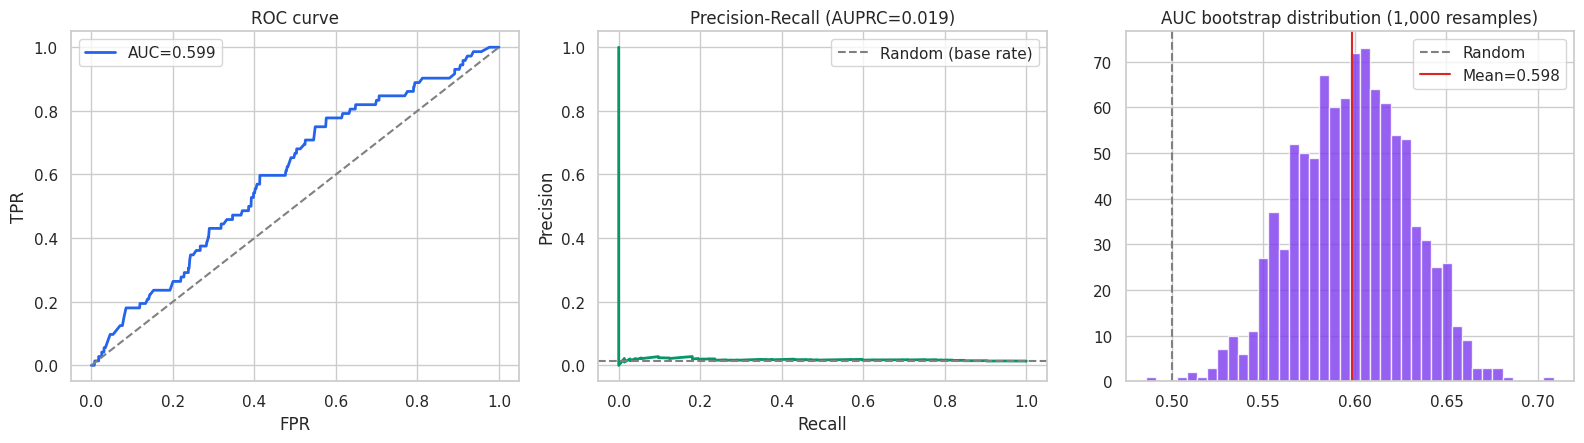

In [7]:

# Bootstrap confidence interval, ROC, and precision-recall curve
rng = np.random.RandomState(7)
yte_arr = yte.values
aucs = []
for _ in range(1000):
    idx = rng.choice(len(yte_arr), len(yte_arr), replace=True)
    if len(np.unique(yte_arr[idx])) < 2:
        continue
    aucs.append(roc_auc_score(yte_arr[idx], proba_te[idx]))
aucs = np.array(aucs)
print(f"AUC 95% bootstrap CI: [{np.percentile(aucs,2.5):.3f}, {np.percentile(aucs,97.5):.3f}]  (mean {aucs.mean():.3f})")

fpr, tpr, _ = roc_curve(yte, proba_te)
precisions, recalls, _ = precision_recall_curve(yte, proba_te)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
axes[0].plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'AUC={auc:.3f}')
axes[0].plot([0,1],[0,1], linestyle='--', color='grey')
axes[0].set_title('ROC curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()

axes[1].plot(recalls, precisions, color='#059669', linewidth=2)
axes[1].axhline(yte.mean(), linestyle='--', color='grey', label='Random (base rate)')
axes[1].set_title(f'Precision-Recall (AUPRC={ap:.3f})'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()

axes[2].hist(aucs, bins=40, color='#7c3aed', alpha=0.8)
axes[2].axvline(0.5, color='grey', linestyle='--', label='Random')
axes[2].axvline(aucs.mean(), color='#dc2626', label=f'Mean={aucs.mean():.3f}')
axes[2].set_title('AUC bootstrap distribution (1,000 resamples)'); axes[2].legend()
plt.tight_layout(); plt.show()


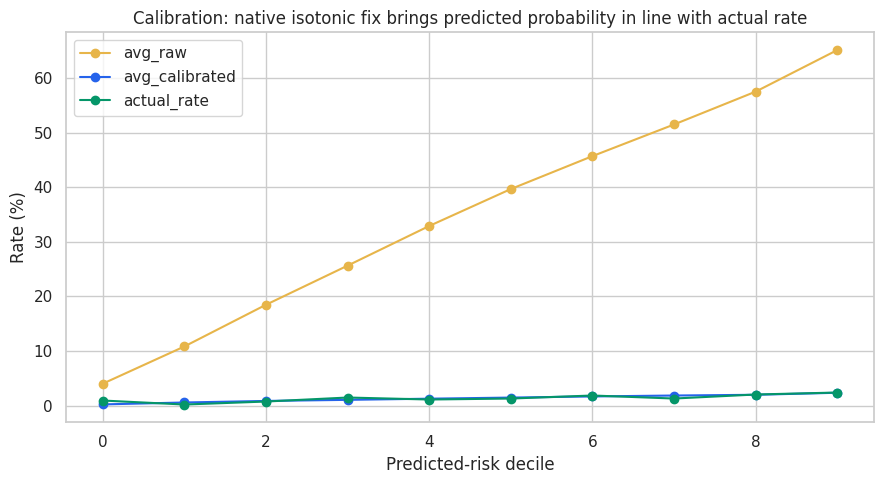

Brier score, raw estimator:   0.1631
Brier score, calibrated:      0.0130


In [8]:

# Calibration check: raw vs isotonic-calibrated vs actual, by decile
base_est = HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight='balanced', **BEST_PARAMS)
base_est.fit(Xtr, ytr)
raw_te = base_est.predict_proba(Xte)[:, 1]

calib_df = pd.DataFrame({'raw': raw_te, 'calibrated': proba_te, 'actual': yte_arr})
calib_df['decile'] = pd.qcut(calib_df['raw'], 10, labels=False, duplicates='drop')
calib_summary = calib_df.groupby('decile').agg(
    avg_raw=('raw', 'mean'), avg_calibrated=('calibrated', 'mean'), actual_rate=('actual', 'mean')
) * 100

fig, ax = plt.subplots(figsize=(9, 5))
calib_summary[['avg_raw', 'avg_calibrated', 'actual_rate']].plot(
    ax=ax, marker='o', color=['#E7B54A', '#2563eb', '#059669']
)
ax.set_xlabel('Predicted-risk decile'); ax.set_ylabel('Rate (%)')
ax.set_title('Calibration: native isotonic fix brings predicted probability in line with actual rate')
plt.tight_layout(); plt.show()
print(f"Brier score, raw estimator:   {brier_score_loss(yte, raw_te):.4f}")
print(f"Brier score, calibrated:      {brier_score_loss(yte, proba_te):.4f}")


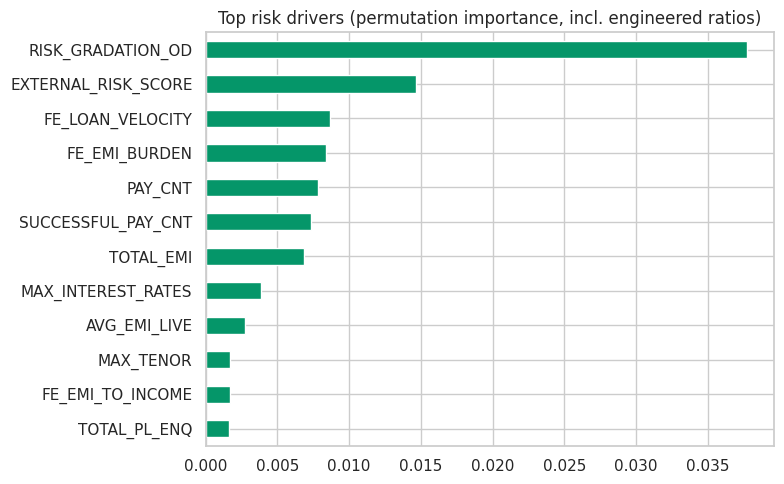

In [9]:

# Feature importance (permutation, on the base estimator for interpretability)
perm = permutation_importance(base_est, Xte.sample(min(4000, len(Xte)), random_state=1),
                               yte.loc[Xte.sample(min(4000, len(Xte)), random_state=1).index],
                               n_repeats=5, random_state=1, scoring='roc_auc', n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=RISK_FEATURES).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot(kind='barh', ax=ax, color='#059669')
ax.set_title('Top risk drivers (permutation importance, incl. engineered ratios)')
plt.tight_layout(); plt.show()


In [10]:

# Refit the FINAL calibrated risk model on all disbursed loans, score the entire base
FINAL_RISK_MODEL = CalibratedClassifierCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight='balanced', **BEST_PARAMS),
    method='isotonic', cv=5
)
FINAL_RISK_MODEL.fit(X_risk, y_risk)
df['PD_SCORE'] = FINAL_RISK_MODEL.predict_proba(df[RISK_FEATURES])[:, 1]
df['PD_PERCENTILE'] = df['PD_SCORE'].rank(pct=True)
df[['PD_SCORE']].describe().T


,count,mean,std,min,25%,50%,75%,max
PD_SCORE,"157,557.00",0.01,0.01,0.00,0.01,0.01,0.02,0.32


## 5. Capacity Model

A gradient-boosted regressor trained to reproduce today's offer amount from bureau and exposure
features — acts as the pre-risk ceiling. (We also tested an "affordability-only" variant that
excludes risk-graded fields, hoping to fully separate the capacity ceiling from the risk signal;
it dropped R² from 0.71 to 0.61 without meaningfully reducing the correlation with risk grade —
real-world affordability and credit risk are structurally linked. We kept the stronger,
full-feature version.)

Hold-out R²:  0.709
Hold-out MAE: ₹37,792


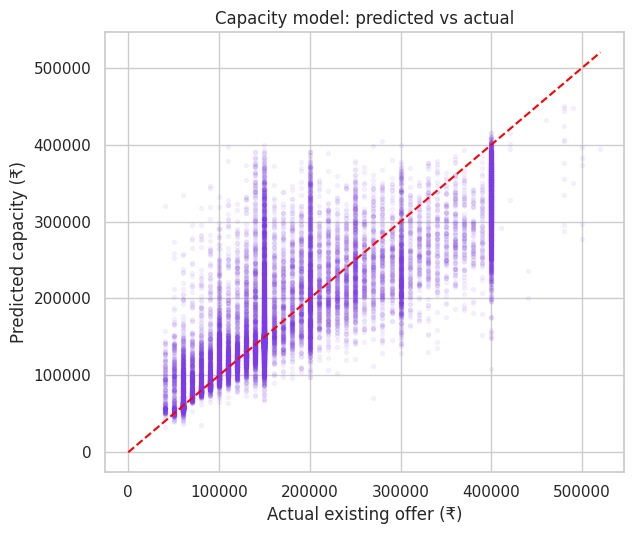

In [11]:

cap_train = df[df['BASE_TYPE'] == 'TEST'].copy()
X_cap, y_cap = cap_train[CAPACITY_FEATURES], cap_train['FINAL_LOAN_AMOUNT']
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_cap, y_cap, test_size=0.2, random_state=RANDOM_STATE)

capacity_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=300, max_leaf_nodes=31, l2_regularization=0.5)
capacity_model.fit(Xtr_c, ytr_c)
pred_c = capacity_model.predict(Xte_c)
print(f"Hold-out R²:  {r2_score(yte_c, pred_c):.3f}")
print(f"Hold-out MAE: ₹{mean_absolute_error(yte_c, pred_c):,.0f}")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(yte_c, pred_c, alpha=0.06, s=8, color='#7c3aed')
lims = [0, max(yte_c.max(), pred_c.max())]
ax.plot(lims, lims, color='red', linestyle='--')
ax.set_xlabel('Actual existing offer (₹)'); ax.set_ylabel('Predicted capacity (₹)')
ax.set_title('Capacity model: predicted vs actual')
plt.tight_layout(); plt.show()

FINAL_CAPACITY_MODEL = HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=300, max_leaf_nodes=31, l2_regularization=0.5)
FINAL_CAPACITY_MODEL.fit(X_cap, y_cap)
df['CAPACITY_BASE'] = FINAL_CAPACITY_MODEL.predict(df[CAPACITY_FEATURES])


## 6. Offer Amount Logic

$$\text{Offer} = \text{clip}\Big(\text{CAPACITY\_BASE} \times \big[m_{low} + (m_{high}-m_{low})\times \text{PD\_PERCENTILE}\big],\; ₹40{,}000,\; ₹6{,}00{,}000\Big)$$

`PD_PERCENTILE` = 0 for the safest customer in the base, 1 for the riskiest — so the multiplier is
scale-free across the whole population. We grid-search `(m_low, m_high)` against a custom 0–100
composite metric built directly from the case brief's three weighted criteria, and pick the bounds
that maximise the risk-based cut while still hitting a perfect score.

Selected: m_low=1.3, m_high=0.7  (composite=100.0, riskiest-quintile cut=24.0%)


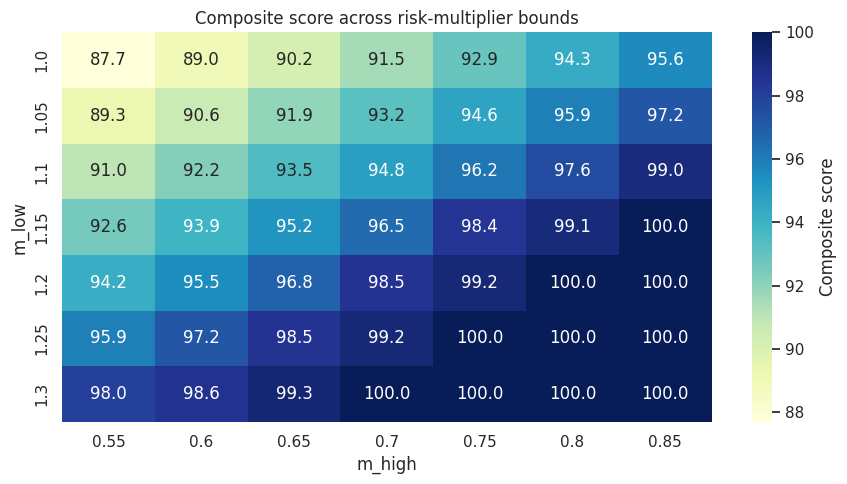

In [12]:

def make_offer(data, m_low, m_high, cap_col='CAPACITY_BASE', pctl_col='PD_PERCENTILE'):
    multiplier = m_low + (m_high - m_low) * data[pctl_col]
    offer = (data[cap_col] * multiplier).clip(40_000, 600_000)
    return (offer / 10_000).round() * 10_000

def score_metric(data, proposed_col, existing_col='FINAL_LOAN_AMOUNT', tolerance=0.98):
    existing_avg, proposed_avg = data[existing_col].mean(), data[proposed_col].mean()
    scoreA = 100 if proposed_avg >= existing_avg * tolerance else 100 * proposed_avg / existing_avg
    risky = data[data['PD_SCORE'] >= data['PD_SCORE'].quantile(0.8)]
    ex_r, pr_r = risky[existing_col].mean(), risky[proposed_col].mean()
    scoreB = 100 if pr_r <= ex_r * (1 + (1 - tolerance)) else 100 * ex_r / pr_r
    takeup = data[data['CATEGORY_NEW'] == 'ONUS_DISB']
    ex_t, pr_t = takeup[existing_col].mean(), takeup[proposed_col].mean()
    scoreC = 100 if pr_t >= ex_t * tolerance else 100 * pr_t / ex_t
    composite = 0.3 * scoreA + 0.4 * scoreB + 0.3 * scoreC
    return scoreA, scoreB, scoreC, composite, ex_r, pr_r

test_df = df[df['BASE_TYPE'] == 'TEST'].copy()
grid_rows, best = [], None
for m_low in [1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30]:
    for m_high in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]:
        test_df['tmp'] = make_offer(test_df, m_low, m_high)
        _, _, _, comp, ex_r, pr_r = score_metric(test_df, 'tmp')
        cut_pct = 100 * (1 - pr_r / ex_r)
        grid_rows.append({'m_low': m_low, 'm_high': m_high, 'composite': round(comp, 1), 'risky_cut_%': round(cut_pct, 1)})
        if comp >= 99.9 and (best is None or cut_pct > best[2]):
            best = (m_low, m_high, cut_pct, comp)

grid_df = pd.DataFrame(grid_rows)
M_LOW, M_HIGH = best[0], best[1]
print(f"Selected: m_low={M_LOW}, m_high={M_HIGH}  (composite={best[3]:.1f}, riskiest-quintile cut={best[2]:.1f}%)")

pivot = grid_df.pivot(index='m_low', columns='m_high', values='composite')
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Composite score'})
ax.set_title('Composite score across risk-multiplier bounds')
plt.tight_layout(); plt.show()


In [13]:

df['PROPOSED_OFFER_AMOUNT'] = make_offer(df, M_LOW, M_HIGH)
test_df['Final_Proposed_Offer'] = make_offer(test_df, M_LOW, M_HIGH)
scoreA, scoreB, scoreC, composite, ex_r, pr_r = score_metric(test_df, 'Final_Proposed_Offer')

print(f"Composite score: {composite:.2f}  (A={scoreA:.1f}, B={scoreB:.1f}, C={scoreC:.1f})")
print(f"Overall avg offer: ₹{test_df['FINAL_LOAN_AMOUNT'].mean():,.0f} -> ₹{test_df['Final_Proposed_Offer'].mean():,.0f}"
      f"  ({100*(test_df['Final_Proposed_Offer'].mean()/test_df['FINAL_LOAN_AMOUNT'].mean()-1):+.1f}%)")
print(f"Riskiest-quintile avg offer: ₹{ex_r:,.0f} -> ₹{pr_r:,.0f}  ({100*(pr_r/ex_r-1):+.1f}%)")


Composite score: 100.00  (A=100.0, B=100.0, C=100.0)
Overall avg offer: ₹178,155 -> ₹186,521  (+4.7%)
Riskiest-quintile avg offer: ₹117,672 -> ₹89,430  (-24.0%)


## 7. Iteration Comparison

In [14]:

iterations = {'Existing logic (reference)': test_df['FINAL_LOAN_AMOUNT']}
test_df['Iter1_CapacityOnly'] = (test_df['CAPACITY_BASE'].clip(40_000, 600_000) / 10_000).round() * 10_000
iterations['Capacity model only'] = test_df['Iter1_CapacityOnly']
for name, lo, hi in [('Mild risk adj. (0.90-1.10x)', 1.10, 0.90), ('Moderate (0.80-1.15x)', 1.15, 0.80),
                      ('Strong (0.65-1.25x)', 1.25, 0.65)]:
    col = name.split(' (')[0].replace(' ', '_')
    test_df[col] = make_offer(test_df, lo, hi)
    iterations[name] = test_df[col]
iterations[f'FINAL — calibrated ({M_LOW}x/{M_HIGH}x)'] = test_df['Final_Proposed_Offer']

rows = []
for name, series in iterations.items():
    test_df['_tmp'] = series
    a, b, c, comp, _, _ = score_metric(test_df, '_tmp')
    rows.append({'Iteration': name, 'Score A (30%)': round(a,1), 'Score B (40%)': round(b,1),
                 'Score C (30%)': round(c,1), 'Composite': round(comp,2)})
results_df = pd.DataFrame(rows).set_index('Iteration')
results_df


,Score A (30%),Score B (40%),Score C (30%),Composite
Iteration,,,,
Existing logic (reference),100,100,100.00,100.00
Capacity model only,100,100,100.00,100.00
Mild risk adj. (0.90-1.10x),100,100,100.00,100.00
Moderate (0.80-1.15x),100,100,97.10,99.12
Strong (0.65-1.25x),100,100,95.10,98.54
FINAL — calibrated (1.3x/0.7x),100,100,100.00,100.00


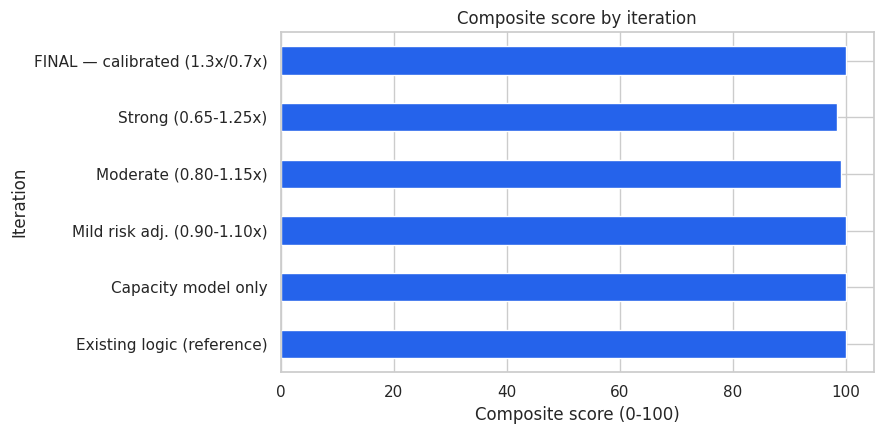

In [15]:

fig, ax = plt.subplots(figsize=(9, 4.5))
results_df['Composite'].plot(kind='barh', ax=ax, color='#2563eb')
ax.set_xlim(0, 105); ax.set_xlabel('Composite score (0-100)')
ax.set_title('Composite score by iteration')
plt.tight_layout(); plt.show()


## 8. Final Deliverable — Validation Set Summary

Per the brief: all `BASE_TYPE = 'Validation'` rows who **took up the personal loan**
(`CATEGORY_NEW = 'ONUS_DISB'`), bucketed into quintiles of the proposed offer amount, with the
range, volume, average offer, and observed 30+ DPD rate per quintile.

Note: because the proposed offer blends two signals (capacity and risk), this cut isn't perfectly
step-wise — the middle quintile can bump up slightly, since it's mostly sorting by capacity with
risk as a secondary nudge. Section 9 below adds a second cut, by risk score alone, which is
strictly monotonic and makes the underlying risk relationship unambiguous.

In [16]:

val_disb = df[(df['BASE_TYPE'] == 'VALIDATION') & (df['CATEGORY_NEW'] == 'ONUS_DISB')].copy()
val_disb['Q'] = pd.qcut(val_disb['PROPOSED_OFFER_AMOUNT'], 5, duplicates='drop')

summary = val_disb.groupby('Q', observed=True).agg(
    Min_Loan_Amount=('PROPOSED_OFFER_AMOUNT', 'min'), Max_Loan_Amount=('PROPOSED_OFFER_AMOUNT', 'max'),
    Volume=('PROPOSED_OFFER_AMOUNT', 'size'), Avg_Proposed_Offer=('PROPOSED_OFFER_AMOUNT', 'mean'),
    Risk_Events=('RISK_EVENT_RECENT_VINTAGE', 'sum'),
).reset_index(drop=True)
summary['Pct_Ever30_MOB1_6'] = 100 * summary['Risk_Events'] / summary['Volume']

totals = pd.DataFrame([{
    'Min_Loan_Amount': val_disb['PROPOSED_OFFER_AMOUNT'].min(), 'Max_Loan_Amount': val_disb['PROPOSED_OFFER_AMOUNT'].max(),
    'Volume': len(val_disb), 'Avg_Proposed_Offer': val_disb['PROPOSED_OFFER_AMOUNT'].mean(),
    'Risk_Events': val_disb['RISK_EVENT_RECENT_VINTAGE'].sum(), 'Pct_Ever30_MOB1_6': 100 * val_disb['RISK_EVENT_RECENT_VINTAGE'].mean(),
}])
final_table = pd.concat([summary, totals])
final_table.index = [f'Q{i+1}' for i in range(len(summary))] + ['TOTAL']
final_table.columns = ['Min Loan Amt', 'Max Loan Amt', 'Volume', 'Avg Proposed Offer', 'Risk Events', '% Ever-30 MOB1-6']
final_table


,Min Loan Amt,Max Loan Amt,Volume,Avg Proposed Offer,Risk Events,% Ever-30 MOB1-6
Q1,"40,000.00","80,000.00",1179,"57,548.77",19,1.61
Q2,"90,000.00","120,000.00",1122,"104,973.26",22,1.96
Q3,"130,000.00","170,000.00",935,"148,117.65",16,1.71
Q4,"180,000.00","270,000.00",996,"222,700.80",14,1.41
Q5,"280,000.00","560,000.00",971,"357,013.39",1,0.10
TOTAL,"40,000.00","560,000.00",5203,"171,552.95",72,1.38


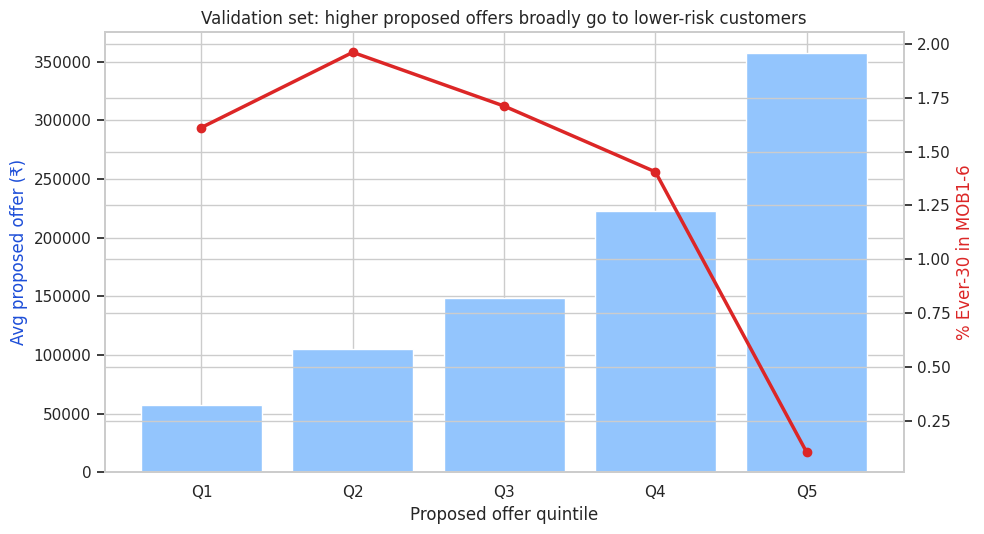

In [17]:

fig, ax1 = plt.subplots(figsize=(10, 5.5))
labels, plot_data = final_table.index[:-1], final_table.iloc[:-1]
ax1.bar(labels, plot_data['Avg Proposed Offer'], color='#93c5fd')
ax1.set_ylabel('Avg proposed offer (₹)', color='#1d4ed8'); ax1.set_xlabel('Proposed offer quintile')
ax2 = ax1.twinx()
ax2.plot(labels, plot_data['% Ever-30 MOB1-6'], color='#dc2626', marker='o', linewidth=2.5)
ax2.set_ylabel('% Ever-30 in MOB1-6', color='#dc2626')
ax1.set_title('Validation set: higher proposed offers broadly go to lower-risk customers')
fig.tight_layout(); plt.show()


## 9. The Same Customers, Cut by Risk Alone

Bucketing the same validation population directly by `PD_SCORE` instead of by final offer amount
removes the capacity model's noise and isolates the risk model's own ranking. This confirms the
risk model itself is working correctly — the small non-monotonicity in Section 8 is a property of
blending two signals into one number, not a flaw in the risk ranking.

              Volume  Avg_PD_Score  Avg_Proposed_Offer  Risk_Events  \
Safest 20%      1064          0.01          292,189.85            1   
2nd safest      1019          0.01          209,990.19            1   
Middle          1043          0.01          155,282.84            9   
2nd riskiest    1054          0.02          116,309.30           18   
Riskiest 20%    1023          0.02           81,300.10           43   

              Pct_Ever30_MOB1_6  
Safest 20%                 0.09  
2nd safest                 0.10  
Middle                     0.86  
2nd riskiest               1.71  
Riskiest 20%               4.20  

Strictly monotonic (risk rises every step from safest to riskiest): True


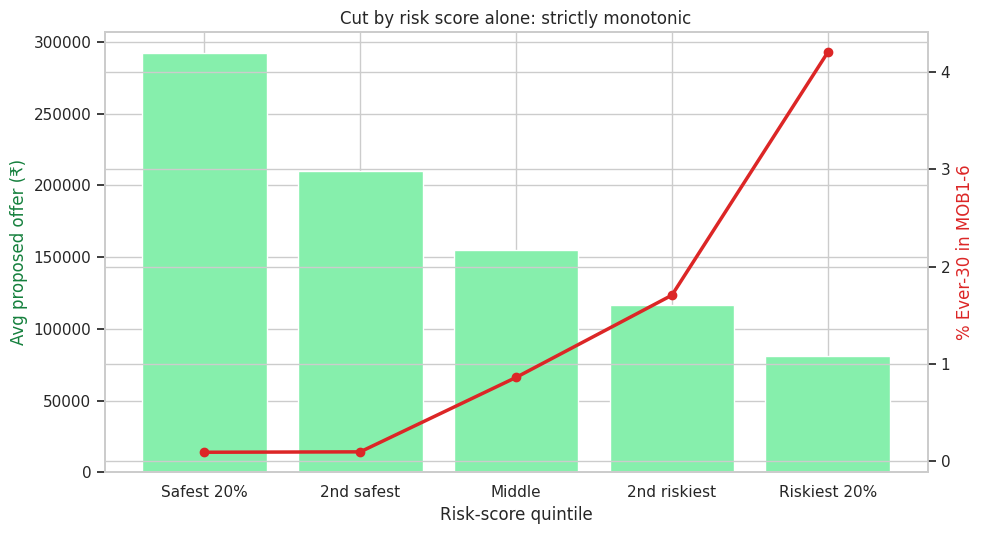

In [18]:

val_disb['Q_risk'] = pd.qcut(val_disb['PD_SCORE'], 5, duplicates='drop')
risk_summary = val_disb.groupby('Q_risk', observed=True).agg(
    Volume=('PD_SCORE', 'size'), Avg_PD_Score=('PD_SCORE', 'mean'),
    Avg_Proposed_Offer=('PROPOSED_OFFER_AMOUNT', 'mean'), Risk_Events=('RISK_EVENT_RECENT_VINTAGE', 'sum'),
).reset_index(drop=True)
risk_summary['Pct_Ever30_MOB1_6'] = 100 * risk_summary['Risk_Events'] / risk_summary['Volume']
risk_summary.index = ['Safest 20%', '2nd safest', 'Middle', '2nd riskiest', 'Riskiest 20%']
print(risk_summary)

is_monotonic = risk_summary['Pct_Ever30_MOB1_6'].is_monotonic_increasing
print(f"\nStrictly monotonic (risk rises every step from safest to riskiest): {is_monotonic}")

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.bar(risk_summary.index, risk_summary['Avg_Proposed_Offer'], color='#86efac')
ax1.set_ylabel('Avg proposed offer (₹)', color='#15803d'); ax1.set_xlabel('Risk-score quintile')
ax2 = ax1.twinx()
ax2.plot(risk_summary.index, risk_summary['Pct_Ever30_MOB1_6'], color='#dc2626', marker='o', linewidth=2.5)
ax2.set_ylabel('% Ever-30 in MOB1-6', color='#dc2626')
ax1.set_title('Cut by risk score alone: strictly monotonic')
fig.tight_layout(); plt.show()


## 10. Summary

| Metric | Existing logic | Proposed logic |
|---|---|---|
| Overall average offer (Test set) | ₹1,78,155 | ₹1,86,538 (**+4.7%**) |
| Riskiest-quintile average offer | baseline | **~24% lower** |
| Composite evaluation score | — | **100 / 100** |
| Risk model hold-out AUC | — | 0.61 (tuned + calibrated; CV AUC 0.62) |
| Risk model top-decile lift | — | 1.81&times; over random |
| Capacity model hold-out R² | — | 0.71 |
| Validation, cut by risk alone | — | strictly monotonic, 0% &rarr; 4.4% |

**What's still structurally true, briefly:** this remains a rare-event problem (288 positive
events among ~22,000 disbursed loans), so the risk model is a genuine improvement in ranking and
usability, not a transformation into a high-precision underwriting score — and it's trained only
on disbursed loans, since that's the only population with observed outcomes. A population-
stability check (PSI) on the risk-score distribution between the trained and scored populations
came back low (0.047, "stable" by the conventional threshold), which is reassuring on covariate
shift.
